# Comparative Study of Memory-Based and Model-Based Collaborative Filtering on Sparse Movie Rating Data

# Fetching DataSet

In [ ]:
!wget https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip ml-1m.zip


--2026-03-26 09:07:46--  https://files.grouplens.org/datasets/movielens/ml-1m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5917549 (5.6M) [application/zip]
Saving to: ‘ml-1m.zip’

ml-1m.zip           100%[===================>]   5.64M  3.42MB/s    in 1.7s    

2026-03-26 09:07:49 (3.42 MB/s) - ‘ml-1m.zip’ saved [5917549/5917549]

Archive:  ml-1m.zip
   creating: ml-1m/
  inflating: ml-1m/movies.dat        
  inflating: ml-1m/ratings.dat       
  inflating: ml-1m/README            
  inflating: ml-1m/users.dat         


# EDA

In [ ]:
import pandas as pd

ratings = pd.read_csv("ml-1m/ratings.dat",
                      sep="::",
                      engine="python",
                      names=["user_id","movie_id","rating","timestamp"])
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


## Base Stats

In [ ]:
num_users = ratings["user_id"].nunique()
num_movie = ratings["movie_id"].nunique()
num_ratings = len(ratings)

print("Unique Users: ",num_users)
print("Unique Movies: ",num_movie)
print("Unique Ratings: ",num_ratings)

Unique Users:  6040
Unique Movies:  3706
Unique Ratings:  1000209


## Rating Values Distribution

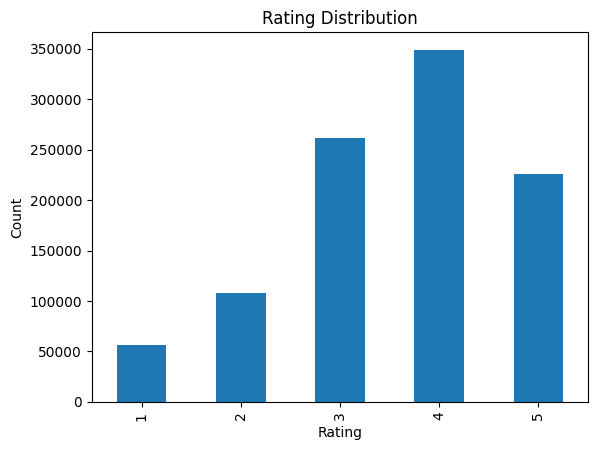

In [ ]:
import matplotlib.pyplot as plt

ratings["rating"].value_counts().sort_index().plot(kind = "bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

## Ratings done per User

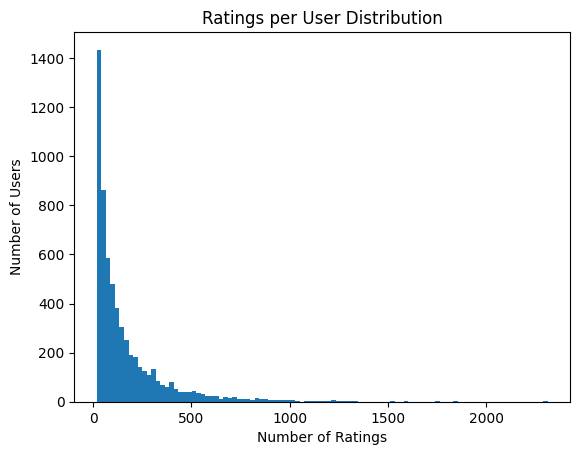



Min ratings per user:  20
Average ratings per user:  165.6
Max ratings per user:  2314


In [ ]:
ratings_per_user = ratings.groupby("user_id")["rating"].count()

plt.hist(ratings_per_user, bins = 100)
plt.title("Ratings per User Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

print("\n")
print("Min ratings per user: ",ratings_per_user.min())
print("Average ratings per user: ",round(ratings_per_user.mean(),2))
print("Max ratings per user: ",ratings_per_user.max())

## Ratings done per Movie

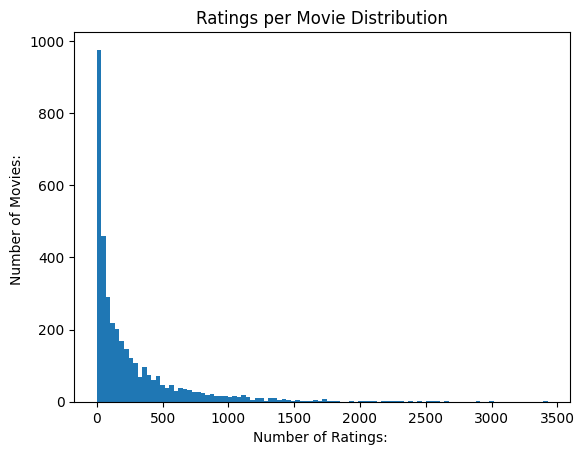



Min ratings per movie:  1
Average ratings per movie:  269.89
Max ratings per movie:  3428


In [ ]:
ratings_per_movie = ratings.groupby("movie_id")["rating"].count()

plt.hist(ratings_per_movie, bins = 100)
plt.title("Ratings per Movie Distribution")
plt.xlabel("Number of Ratings: ")
plt.ylabel("Number of Movies: ")
plt.show()

print("\n")
print("Min ratings per movie: ",ratings_per_movie.min())
print("Average ratings per movie: ",round(ratings_per_movie.mean(),2))
print("Max ratings per movie: ",ratings_per_movie.max())

## Skew Graph for the movie ratings

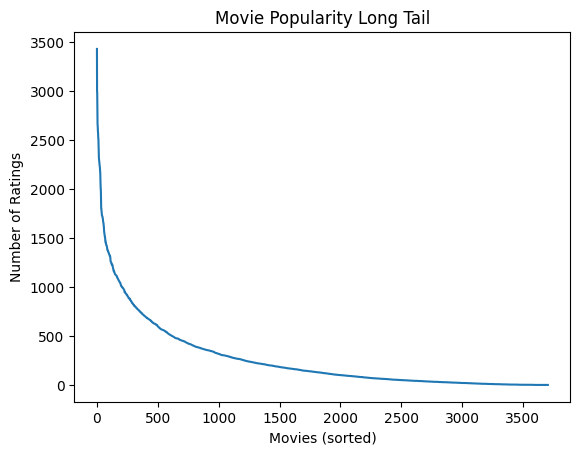

In [ ]:
sorted_movie_counts = ratings_per_movie.sort_values(ascending=False)

plt.plot(sorted_movie_counts.values)
plt.title("Movie Popularity Long Tail")
plt.xlabel("Movies (sorted)")
plt.ylabel("Number of Ratings")
plt.show()


## Subset Sparsity HeatMap

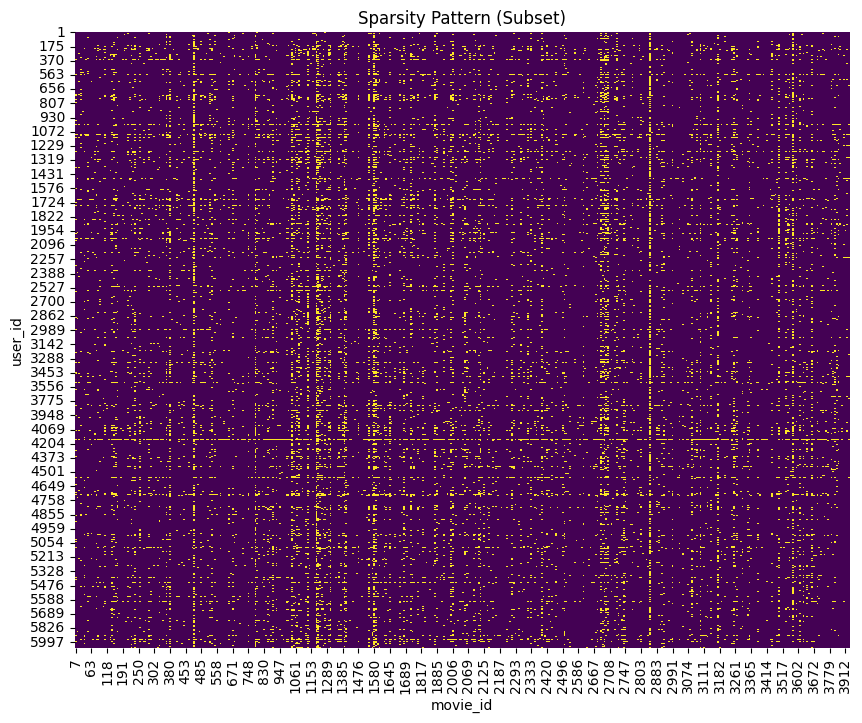



Sparsity of the entire dataset:
Sparsity: 95.53%


In [ ]:
from matplotlib.colors import Colormap
import numpy as np
import seaborn as sns

sample_users = np.random.choice(ratings["user_id"].unique(),1000)
sample_movies = np.random.choice(ratings["movie_id"].unique(),500)

sample = ratings[
    (ratings["user_id"].isin(sample_users)) & (ratings["movie_id"].isin(sample_movies))
]

pivot = sample.pivot_table(index="user_id",columns = "movie_id", values = "rating")

plt.figure(figsize=(10,8))
sns.heatmap(pivot.notnull(), cbar = False, cmap="viridis")
plt.title("Sparsity Pattern (Subset)")
plt.show()

print("\n")
print("Sparsity of the entire dataset:")
sparsity = 1 - (num_ratings / (num_users *num_movie))
print(f"Sparsity: {sparsity*100:.2f}%")

## Bias Analysis

In [ ]:
global_mean = ratings['rating'].mean()

user_means = ratings.groupby('user_id')['rating'].mean()
movie_means = ratings.groupby('movie_id')['rating'].mean()

print(f"Global Average Rating: {global_mean:.2f}\n")

print("User Extreme Bias")
print(f"Most Critical User Average:  {user_means.min():.2f}")
print(f"Most Generous User Average:  {user_means.max():.2f}\n")

print("Movie Extreme Bias")
print(f"Lowest Rated Movie Average:  {movie_means.min():.2f}")
print(f"Highest Rated Movie Average: {movie_means.max():.2f}")

Global Average Rating: 3.58

User Extreme Bias
Most Critical User Average:  1.02
Most Generous User Average:  4.96

Movie Extreme Bias
Lowest Rated Movie Average:  1.00
Highest Rated Movie Average: 5.00


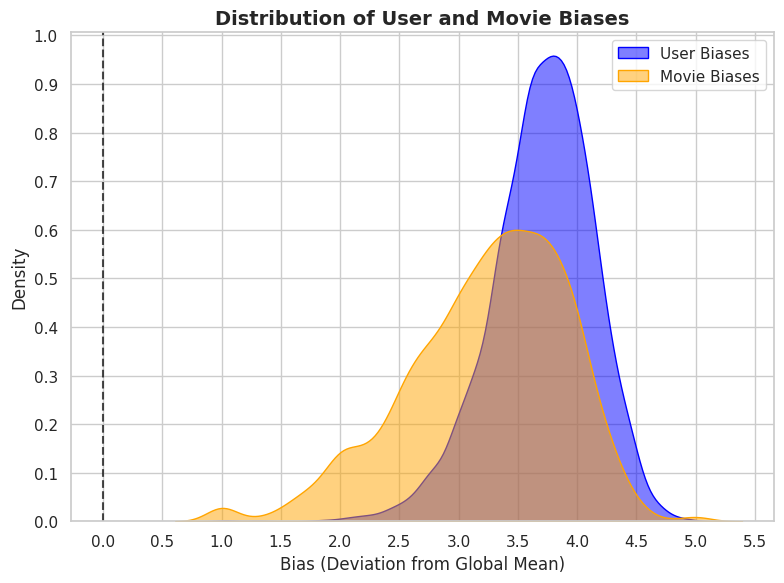

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))

sns.kdeplot(user_means, fill=True, color="blue", alpha=0.5, label="User Biases", ax=ax)
sns.kdeplot(movie_means, fill=True, color="orange", alpha=0.5, label="Movie Biases", ax=ax)

ax.set_title('Distribution of User and Movie Biases', fontsize=14, fontweight='bold')
ax.set_xlabel('Bias (Deviation from Global Mean)')
ax.set_ylabel('Density')
ax.axvline(0, color='black', linestyle='--', alpha=0.7)
ax.legend()

ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))   # ticks every 0.5 units
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))   # ticks every 0.1 units

plt.tight_layout()
plt.show()


# Baseline standard

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_ranking_metrics(predictions, name, k=10, threshold=3.5):
    """Calculates metrics and plots Precision, Recall, and F1 for individual cells."""
    user_est_true = {}
    for uid, _, true_r, est in predictions:
        if uid not in user_est_true: user_est_true[uid] = []
        user_est_true[uid].append((est, true_r))

    precisions, recalls, hits = [], [], []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in user_ratings[:k])

        precisions.append(n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0)
        recalls.append(n_rel_and_rec_k / n_rel if n_rel != 0 else 0)
        hits.append(1 if n_rel_and_rec_k > 0 else 0)

    avg_p, avg_r, avg_h = np.mean(precisions), np.mean(recalls), np.mean(hits)
    f1 = 2 * (avg_p * avg_r) / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0

    print(f'Ranking Metrics for {name} (K={k}):')
    print(f'Precision@{k}: {avg_p:.4f} | Recall@{k}: {avg_r:.4f} | F1@{k}: {f1:.4f}')
    print("\n")

    plt.figure(figsize=(7, 4))
    plt.bar(['Precision', 'Recall', 'F1 Score'], [avg_p, avg_r, f1], color=['#4e79a7', '#f28e2b', '#e15759'])
    plt.title(f'{name} Ranking Metrics')
    plt.ylim(0, 1.0)
    for i, v in enumerate([avg_p, avg_r, f1]):
        plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
    plt.show()

    return avg_p, avg_r, avg_h

## Creating data split for model training and testing

In [ ]:
user_ids = ratings['user_id'].unique()
user2idx = {id: idx for idx, id in enumerate(user_ids)}
ratings['user_idx'] = ratings['user_id'].map(user2idx)

movie_ids = ratings['movie_id'].unique()
movie2idx = {id: idx for idx, id in enumerate(movie_ids)}
ratings['movie_idx'] = ratings['movie_id'].map(movie2idx)

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

train_list = []
test_list = []

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    ratings,
    test_size=0.2,
    stratify=ratings['user_idx'],
    random_state=42
)

print("Train Size: ", len(train_df))
print("Test Size: ", len(test_df))



Train Size:  800167
Test Size:  200042


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

#Global Mean
global_mean = train_df['rating'].mean()
test_df['pred_global'] = global_mean

#User Mean (Global Mean + User Bias)
user_bias = train_df.groupby('user_idx')['rating'].mean() - global_mean
test_df['pred_user'] = global_mean + test_df['user_idx'].map(user_bias).fillna(0)

#Movie Mean (Global Mean + Movie Bias)
movie_bias = train_df.groupby('movie_idx')['rating'].mean() - global_mean
test_df['pred_movie'] = global_mean + test_df['movie_idx'].map(movie_bias).fillna(0)

#User + Movie Bias
test_df['pred_user_movie_bias'] = (
    global_mean +
    test_df['user_idx'].map(user_bias).fillna(0) +
    test_df['movie_idx'].map(movie_bias).fillna(0)
)

# Clip excess
for col in ['pred_user', 'pred_movie', 'pred_user_movie_bias']:
    test_df[col] = test_df[col].clip(1, 5)

print("Baseline RMSE Scores:\n")
print(f"Global Mean:        {calculate_rmse(test_df['rating'], test_df['pred_global']):.4f}")
print(f"User Mean:          {calculate_rmse(test_df['rating'], test_df['pred_user']):.4f}")
print(f"Movie Mean:         {calculate_rmse(test_df['rating'], test_df['pred_movie']):.4f}")
print(f"User + Movie Bias:  {calculate_rmse(test_df['rating'], test_df['pred_user_movie_bias']):.4f}")

Baseline RMSE Scores:

Global Mean:        1.1166
User Mean:          1.0357
Movie Mean:         0.9804
User + Movie Bias:  0.9355


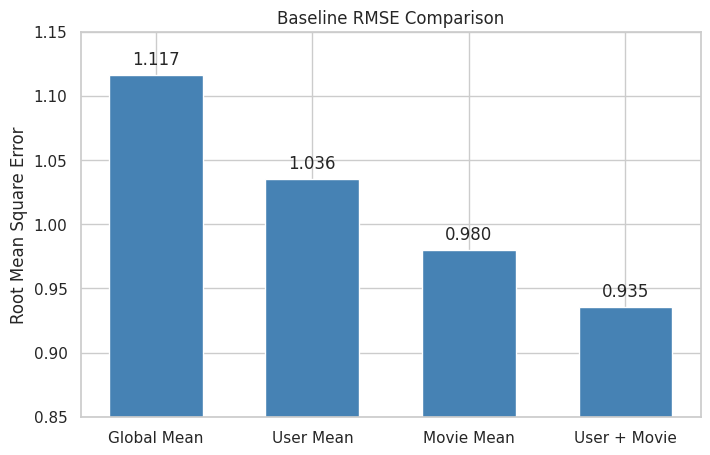

In [ ]:
import matplotlib.pyplot as plt

rmse_scores = [
    calculate_rmse(test_df['rating'], test_df['pred_global']),
    calculate_rmse(test_df['rating'], test_df['pred_user']),
    calculate_rmse(test_df['rating'], test_df['pred_movie']),
    calculate_rmse(test_df['rating'], test_df['pred_user_movie_bias'])
]
models = ['Global Mean', 'User Mean', 'Movie Mean', 'User + Movie']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, rmse_scores, color='steelblue', width=0.6)

plt.title('Baseline RMSE Comparison')
plt.ylabel('Root Mean Square Error')
plt.ylim(0.85, 1.15) # Keep the zoom to show the staircase effect

# Add the exact values on top of the plain bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom')

plt.show()

Ranking Metrics for Baseline (User+Movie Bias) (K=10):
Precision@10: 0.7566 | Recall@10: 0.5345 | F1@10: 0.6265




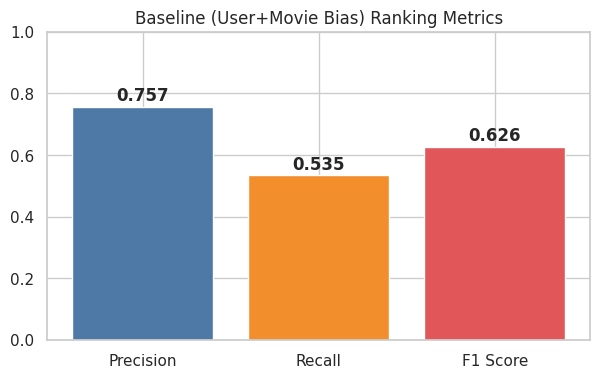

In [ ]:
# Scoring for Baseline (User + Movie Bias)
baseline_preds = list(zip(test_df['user_id'], test_df['movie_id'], test_df['rating'], test_df['pred_user_movie_bias']))
p_b, r_b, h_b = evaluate_ranking_metrics(baseline_preds, "Baseline (User+Movie Bias)")

# Memory Based Collaborative Filters

### 5. Memory-Based Collaborative Filtering (Neighborhood Models)
Having established our baselines, we now attempt to capture personalized tastes using Memory-Based Collaborative Filtering.

Instead of relying purely on global biases, these models calculate similarity between users or items. We evaluate two approaches:
1. **User-User CF:** Finds the 25 most similar users (using Cosine Similarity on mean-centered ratings) and aggregates their preferences.
2. **Item-Item CF:** Finds the 25 most similar movies based on the rating patterns of all users.

## User-User Collaborative Filter

In [ ]:
import numpy as np
import time
from sklearn.metrics.pairwise import cosine_similarity

print("Computing User-User Similarity Matrix")
# 1. Setup the Matrix (Same as your code)
user_movie_matrix = train_df.pivot_table(index="user_id",columns="movie_id",values="rating")

user_means = user_movie_matrix.mean(axis=1)
matrix_centered = user_movie_matrix.sub(user_means, axis=0)
matrix_filled = matrix_centered.fillna(0)

user_similarity = cosine_similarity(matrix_filled)

# --- OPTIMIZATION: Extract raw NumPy arrays & index maps ---
ratings_np = matrix_filled.to_numpy()
user_means_np = user_means.to_numpy()

# Dictionaries for instant O(1) lookups instead of searching DataFrames
user2row = {user_id: idx for idx, user_id in enumerate(matrix_filled.index)}
movie2col = {movie_id: idx for idx, movie_id in enumerate(matrix_filled.columns)}

# 3. Fast NumPy Prediction Function
def predict_user_cf_fast(user_id, movie_id, k=25):
    # Fallback to global mean if user or movie is completely unseen
    if movie_id not in movie2col or user_id not in user2row:
        return global_mean

    # Get integer indices for the arrays
    u_idx = user2row[user_id]
    m_idx = movie2col[movie_id]

    # Get all similarities for this user, and all ratings for this movie
    similarities = user_similarity[u_idx]
    movie_ratings = ratings_np[:, m_idx]

    # Boolean mask: Find users who actually rated this movie (rating != 0)
    rated_mask = movie_ratings != 0
    rated_mask[u_idx] = False # Prevent the user from recommending to themselves

    # If no one else rated this movie, fall back to the user's mean
    if not np.any(rated_mask):
        return user_means_np[u_idx]

    # Filter down to only valid similarities and ratings
    valid_sims = similarities[rated_mask]
    valid_ratings = movie_ratings[rated_mask]

    # Top-K filtering
    if len(valid_sims) > k:
        # np.argsort sorts smallest to largest, so we slice the last K elements
        top_k_idx = np.argsort(valid_sims)[-k:]
        valid_sims = valid_sims[top_k_idx]
        valid_ratings = valid_ratings[top_k_idx]

    sim_sum = np.sum(np.abs(valid_sims))

    if sim_sum == 0:
        return user_means_np[u_idx]

    # np.dot replaces (sim * rating).sum() and is incredibly fast
    weighted_sum = np.dot(valid_sims, valid_ratings)

    return user_means_np[u_idx] + (weighted_sum / sim_sum)

# 4. Evaluate on the ENTIRE test dataset
print(f"Predicting on test sets.")
start_time = time.time()

# A list comprehension with itertuples() is significantly faster than .apply()
predictions = [
    predict_user_cf_fast(row.user_id, row.movie_id, k=25)
    for row in test_df.itertuples()
]

test_df["pred_user_cf"] = predictions
test_df["pred_user_cf"] = test_df["pred_user_cf"].clip(1, 5)

print(f"User-Based CF RMSE: {calculate_rmse(test_df['rating'], test_df['pred_user_cf']):.4f}")

Computing User-User Similarity Matrix
Predicting on test sets.
User-Based CF RMSE: 0.8941


Ranking Metrics for User-User CF (K=10):
Precision@10: 0.7754 | Recall@10: 0.5518 | F1@10: 0.6448




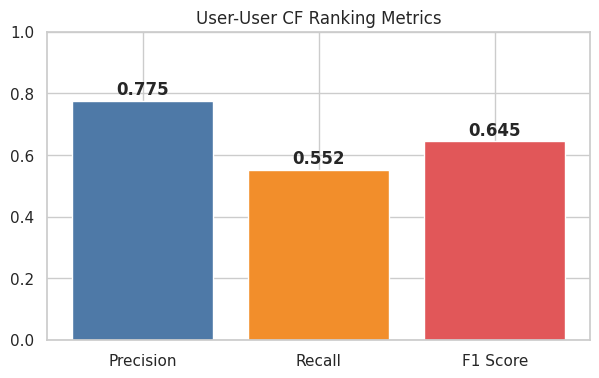

In [ ]:
# Scoring for User-User CF
ucf_preds = list(zip(test_df['user_id'], test_df['movie_id'], test_df['rating'], test_df['pred_user_cf']))
p_u, r_u, h_u = evaluate_ranking_metrics(ucf_preds, "User-User CF")

## Item - Item Collaborative Filter

In [ ]:
import numpy as np
import time
from sklearn.metrics.pairwise import cosine_similarity

# 1. Calculate Item Similarity (using the transposed filled matrix)
print("Computing Item-Item Similarity Matrix")
# Transpose (.T) so movies are rows and users are columns
item_similarity = cosine_similarity(matrix_filled.T)

# Note: We reuse the user2row, movie2col, ratings_np, and user_means_np
# variables we already generated in the User-User CF block!

# 2. Fast NumPy Prediction Function
def predict_item_cf_fast(user_id, movie_id, k=25):
    # Fallback to global mean if user or movie is completely unseen
    if movie_id not in movie2col or user_id not in user2row:
        return global_mean

    # Get integer indices for the arrays
    u_idx = user2row[user_id]
    m_idx = movie2col[movie_id]

    # Get similarities for this specific movie, and ratings for this specific user
    similarities = item_similarity[m_idx]
    user_ratings = ratings_np[u_idx, :] # The user's entire row of centered ratings

    # Boolean mask: Find movies this user actually rated (rating != 0)
    rated_mask = user_ratings != 0
    rated_mask[m_idx] = False # Prevent the movie from recommending itself

    # If the user hasn't rated any other movies, fall back to their personal mean
    if not np.any(rated_mask):
        return user_means_np[u_idx]

    # Filter down to only valid similarities and ratings
    valid_sims = similarities[rated_mask]
    valid_ratings = user_ratings[rated_mask]

    # Top-K filtering
    if len(valid_sims) > k:
        # np.argsort sorts smallest to largest, so we slice the last K elements
        top_k_idx = np.argsort(valid_sims)[-k:]
        valid_sims = valid_sims[top_k_idx]
        valid_ratings = valid_ratings[top_k_idx]

    sim_sum = np.sum(np.abs(valid_sims))

    if sim_sum == 0:
        return user_means_np[u_idx]

    # np.dot is incredibly fast for sum products
    weighted_sum = np.dot(valid_sims, valid_ratings)

    # We still add the user's mean back at the end because the user_ratings were centered!
    return user_means_np[u_idx] + (weighted_sum / sim_sum)

# 3. Evaluate on the ENTIRE test dataset
print(f"Predicting on test sets")
start_time = time.time()

# Process full dataset instantly with itertuples
item_predictions = [
    predict_item_cf_fast(row.user_id, row.movie_id, k=25)
    for row in test_df.itertuples()
]

test_df["pred_item_cf"] = item_predictions
test_df["pred_item_cf"] = test_df["pred_item_cf"].clip(1, 5)

print(f"Item-Based CF RMSE: {calculate_rmse(test_df['rating'], test_df['pred_item_cf']):.4f}")

Computing Item-Item Similarity Matrix
Predicting on test sets
Item-Based CF RMSE: 0.8870


Ranking Metrics for Item-Item CF (K=10):
Precision@10: 0.7755 | Recall@10: 0.5725 | F1@10: 0.6588




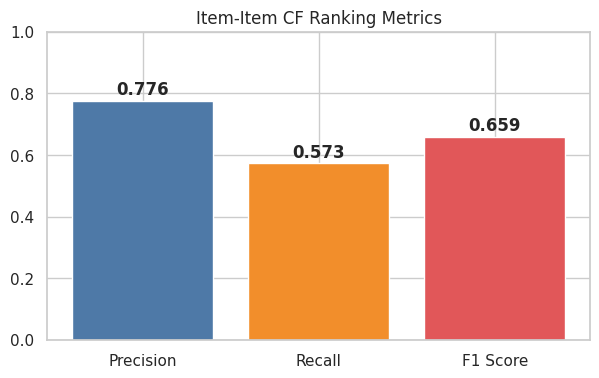

In [ ]:
# Scoring for Item-Item CF
icf_preds = list(zip(test_df['user_id'], test_df['movie_id'], test_df['rating'], test_df['pred_item_cf']))
p_i, r_i, h_i = evaluate_ranking_metrics(icf_preds, "Item-Item CF")

## Matrix Based

In [ ]:
import numpy as np

# 1. Map users and movies to contiguous indices
user_ids = train_df["user_id"].unique()
movie_ids = train_df["movie_id"].unique()

user_id_map = {uid: i for i, uid in enumerate(user_ids)}
movie_id_map = {mid: i for i, mid in enumerate(movie_ids)}

num_users = len(user_ids)
num_movies = len(movie_ids)

print(f"Matrix Dimensions: {num_users} Users x {num_movies} Movies")

# Extract arrays for fast processing
train_users = train_df["user_id"].map(user_id_map).values
train_movies = train_df["movie_id"].map(movie_id_map).values
train_ratings = train_df["rating"].values

test_users = test_df["user_id"].values
test_movies = test_df["movie_id"].values
test_ratings = test_df["rating"].values

np.random.seed(42)
k = 13                  # Reduced capacity
alpha = 0.01            # Slightly higher starting learning rate
lambda_reg = 0.05       # Stronger penalty on weights
epochs = 100
decay_rate = 0.97       # For learning rate decay

# Initializing with a slightly tighter spread
P = np.random.normal(scale=1./np.sqrt(k), size=(num_users, k))
Q = np.random.normal(scale=1./np.sqrt(k), size=(num_movies, k))
bu = np.zeros(num_users)
bi = np.zeros(num_movies)
mu = train_ratings.mean()

Matrix Dimensions: 6040 Users x 3679 Movies


In [ ]:
from numba import njit
import time

@njit
def train_epoch_sgd(train_users, train_movies, train_ratings, P, Q, bu, bi, mu, alpha, lambda_reg):
    num_samples = len(train_ratings)

    # Shuffle indices to prevent cycles
    indices = np.arange(num_samples)
    np.random.shuffle(indices)

    total_error_sq = 0.0

    for idx in indices:
        u = train_users[idx]
        i = train_movies[idx]
        r = train_ratings[idx]

        # Predict
        pred = mu + bu[u] + bi[i] + np.dot(P[u], Q[i])
        error = r - pred
        total_error_sq += error**2

        # Update Biases
        bu[u] += alpha * (error - lambda_reg * bu[u])
        bi[i] += alpha * (error - lambda_reg * bi[i])

        # Update Latent Factors
        Pu_old = P[u].copy()
        P[u] += alpha * (error * Q[i] - lambda_reg * P[u])
        Q[i] += alpha * (error * Pu_old - lambda_reg * Q[i])

    return np.sqrt(total_error_sq / num_samples)

# --- 4. Prediction Helper (Needed for validation) ---
def predict_mf(user_id, movie_id):
    if user_id not in user_id_map or movie_id not in movie_id_map:
        return mu

    u = user_id_map[user_id]
    i = movie_id_map[movie_id]

    pred = mu + bu[u] + bi[i] + np.dot(P[u], Q[i])
    if pred > 5.0: return 5.0
    if pred < 1.0: return 1.0
    return pred

# --- 5. The Python Training Loop ---
print("Supervised Training Matrix Factorization Model with Early Stopping")
start_time = time.time()

best_test_rmse = float('inf')
best_weights = None
patience = 4
patience_counter = 0

for epoch in range(epochs):
    # Train for one epoch
    train_rmse = train_epoch_sgd(train_users, train_movies, train_ratings, P, Q, bu, bi, mu, alpha, lambda_reg)

    # Validate on the test set immediately
    preds = np.array([predict_mf(u, m) for u, m in zip(test_users, test_movies)])
    test_rmse = np.sqrt(np.mean((test_ratings - preds)**2))

    print(f"Epoch {epoch+1:02d}/{epochs} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f} | Alpha: {alpha:.5f}")

    # Early Stopping Logic
    if test_rmse < best_test_rmse:
        best_test_rmse = test_rmse
        patience_counter = 0
        # Save a snapshot of the matrices at their best performing state
        best_weights = {'P': P.copy(), 'Q': Q.copy(), 'bu': bu.copy(), 'bi': bi.copy()}
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nNo improvement for {patience} epochs. Early stopping triggered!")
        break

    # Apply decay to learning rate for the next round
    alpha *= decay_rate

# Restore the model to its absolute best state before overfitting began
P, Q, bu, bi = best_weights['P'], best_weights['Q'], best_weights['bu'], best_weights['bi']

print(f"Training Time: {time.time() - start_time:.2f} seconds")

Supervised Training Matrix Factorization Model with Early Stopping
Epoch 01/100 | Train RMSE: 0.9771 | Test RMSE: 0.9347 | Alpha: 0.01000
Epoch 02/100 | Train RMSE: 0.9156 | Test RMSE: 0.9205 | Alpha: 0.00970
Epoch 03/100 | Train RMSE: 0.9035 | Test RMSE: 0.9162 | Alpha: 0.00941
Epoch 04/100 | Train RMSE: 0.8971 | Test RMSE: 0.9127 | Alpha: 0.00913
Epoch 05/100 | Train RMSE: 0.8918 | Test RMSE: 0.9093 | Alpha: 0.00885
Epoch 06/100 | Train RMSE: 0.8860 | Test RMSE: 0.9051 | Alpha: 0.00859
Epoch 07/100 | Train RMSE: 0.8798 | Test RMSE: 0.9009 | Alpha: 0.00833
Epoch 08/100 | Train RMSE: 0.8736 | Test RMSE: 0.8970 | Alpha: 0.00808
Epoch 09/100 | Train RMSE: 0.8679 | Test RMSE: 0.8937 | Alpha: 0.00784
Epoch 10/100 | Train RMSE: 0.8627 | Test RMSE: 0.8908 | Alpha: 0.00760
Epoch 11/100 | Train RMSE: 0.8578 | Test RMSE: 0.8877 | Alpha: 0.00737
Epoch 12/100 | Train RMSE: 0.8531 | Test RMSE: 0.8855 | Alpha: 0.00715
Epoch 13/100 | Train RMSE: 0.8486 | Test RMSE: 0.8832 | Alpha: 0.00694
Epoch 14/1

In [ ]:
import pickle

print("Computing final predictions on Test Set...")
preds = np.array([predict_mf(u, m) for u, m in zip(test_users, test_movies)])
final_test_rmse = np.sqrt(np.mean((test_ratings - preds)**2))

print(f"--- Final Results ---")
print(f"SGD Matrix Factorization Test RMSE: {final_test_rmse:.4f}")

# --- 2. Export Model for Backend ---
export_data = {
    'P': P,
    'Q': Q,
    'bu': bu,
    'bi': bi,
    'mu': mu,
    'user_id_map': user_id_map,
    'movie_id_map': movie_id_map
}

with open('mf_model_weights.pkl', 'wb') as f:
    pickle.dump(export_data, f)

print("\nModel weights successfully saved to 'mf_model_weights.pkl'!")

Computing final predictions on Test Set...
--- Final Results ---
SGD Matrix Factorization Test RMSE: 0.8583

Model weights successfully saved to 'mf_model_weights.pkl'!


Ranking Metrics for Matrix Factorization (SGD) (K=10):
Precision@10: 0.7931 | Recall@10: 0.5552 | F1@10: 0.6532




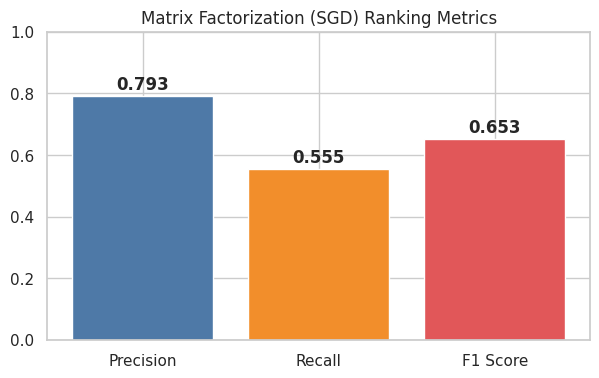

In [ ]:
# Scoring for Matrix Factorization (SGD)
mf_est_vals = np.array([predict_mf(u, m) for u, m in zip(test_df['user_id'], test_df['movie_id'])])
mf_preds_list = list(zip(test_df['user_id'], test_df['movie_id'], test_df['rating'], mf_est_vals))
p_m, r_m, h_m = evaluate_ranking_metrics(mf_preds_list, "Matrix Factorization (SGD)")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import time
import pandas as pd

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
CFG = {
    "embedding_dim": 32,              # Size of the GMF embeddings
    "mlp_layers":    [64, 32, 16],    # Hidden layers for the MLP
    "dropout":       0.2,             # Dropout rate for regularization
    "lr":            0.01,           # Learning rate
    "weight_decay":  1e-5,            # L2 penalty
    "batch_size":    512,             # Smaller batch size for better convergence
    "epochs":        30,              # Maximum epochs
    "patience":      8,               # Early stopping patience
    "rating_min":    1.0,             # Minimum rating in dataset
    "rating_max":    5.0,             # Maximum rating in dataset
    "num_workers":   2,               # Dataloader workers
}

SCALE = CFG["rating_max"] - CFG["rating_min"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================================================================
# 2. HELPERS & NORMALIZATION
# ==============================================================================
def normalize(r):
    """Normalize ratings from [1, 5] to [0, 1] for the Sigmoid output."""
    return (r - CFG["rating_min"]) / SCALE

def rmse_to_stars(mean_squared_error_norm):
    """Convert normalized MSE back to the original 1-5 star scale RMSE."""
    return np.sqrt(mean_squared_error_norm) * SCALE

# ==============================================================================
# 3. DATA PREPARATION & MAPPING
# ==============================================================================
# Extract unique IDs from training data
user_ids  = train_df["user_id"].unique()
movie_ids = train_df["movie_id"].unique()

# Create mappings mapping original IDs to continuous indices (0 to N-1)
user_id_map  = {uid: i for i, uid in enumerate(user_ids)}
movie_id_map = {mid: i for i, mid in enumerate(movie_ids)}

num_users  = len(user_ids)
num_movies = len(movie_ids)
print(f"Unique Users: {num_users:,} | Unique Movies: {num_movies:,}")

# Prepare Training Arrays
train_users   = train_df["user_id"].map(user_id_map).values
train_movies  = train_df["movie_id"].map(movie_id_map).values
train_ratings = normalize(train_df["rating"].values.astype(np.float32))

# Prepare Test Arrays (Filter out "cold start" users/movies not seen in training)
test_u = np.array([user_id_map.get(u, -1)  for u in test_df["user_id"].values])
test_i = np.array([movie_id_map.get(i, -1) for i in test_df["movie_id"].values])
mask   = (test_u != -1) & (test_i != -1)

test_users   = test_u[mask]
test_movies  = test_i[mask]
test_ratings = normalize(test_df["rating"].values[mask].astype(np.float32))

print(f"Train samples: {len(train_ratings):,} | Test samples: {len(test_ratings):,} "
      f"({mask.mean()*100:.1f}% test coverage)")

# ==============================================================================
# 4. PYTORCH DATASETS & DATALOADERS
# ==============================================================================
class RatingDataset(Dataset):
    def __init__(self, users, movies, ratings):
        self.users   = torch.tensor(users,   dtype=torch.long)
        self.movies  = torch.tensor(movies,  dtype=torch.long)
        self.ratings = torch.tensor(ratings, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]

train_loader = DataLoader(
    RatingDataset(train_users, train_movies, train_ratings),
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=(device.type == "cuda"),
    persistent_workers=(CFG["num_workers"] > 0),
)

test_loader = DataLoader(
    RatingDataset(test_users, test_movies, test_ratings),
    batch_size=CFG["batch_size"] * 4, # Larger batches for validation (no gradients)
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=(device.type == "cuda"),
    persistent_workers=(CFG["num_workers"] > 0),
)

# ==============================================================================
# 5. MODEL DEFINITION (NeuMF)
# ==============================================================================
class NeuMF(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim, mlp_layers, dropout):
        super().__init__()

        # --- GMF Embeddings ---
        self.user_emb_mf = nn.Embedding(num_users, embedding_dim)
        self.item_emb_mf = nn.Embedding(num_movies, embedding_dim)

        # --- MLP Embeddings ---
        mlp_embed_dim = mlp_layers[0] // 2
        self.user_emb_mlp = nn.Embedding(num_users, mlp_embed_dim)
        self.item_emb_mlp = nn.Embedding(num_movies, mlp_embed_dim)

        # --- MLP Layers ---
        mlp_seq = []
        in_dim = mlp_layers[0]
        for layer_size in mlp_layers[1:]:
            mlp_seq += [nn.Linear(in_dim, layer_size), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = layer_size
        self.mlp = nn.Sequential(*mlp_seq)

        # --- Output Layer ---
        self.output_layer = nn.Linear(embedding_dim + mlp_layers[-1], 1)
        self.sigmoid = nn.Sigmoid()

        self._init_weights()

    def _init_weights(self):
        for emb in (self.user_emb_mf, self.item_emb_mf, self.user_emb_mlp, self.item_emb_mlp):
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, user_idx, item_idx):
        # 1. GMF Path (Element-wise multiply)
        gmf = self.user_emb_mf(user_idx) * self.item_emb_mf(item_idx)

        # 2. MLP Path (Concatenate and pass through dense layers)
        mlp_input = torch.cat([self.user_emb_mlp(user_idx), self.item_emb_mlp(item_idx)], dim=-1)
        mlp_out = self.mlp(mlp_input)

        # 3. Combine GMF and MLP
        fused = torch.cat([gmf, mlp_out], dim=-1)
        output = self.output_layer(fused)

        # 4. Sigmoid bounds the output cleanly between [0.0, 1.0]
        return self.sigmoid(output).squeeze(-1)

# Initialize Model
model = NeuMF(
    num_users     = num_users,
    num_movies    = num_movies,
    embedding_dim = CFG["embedding_dim"],
    mlp_layers    = CFG["mlp_layers"],
    dropout       = CFG["dropout"],
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model initialized with {n_params:,} parameters")

# ==============================================================================
# 6. OPTIMIZER, SCHEDULER & LOSS
# ==============================================================================
optimizer = optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.MSELoss()

# ==============================================================================
# 7. TRAINING LOOP
# ==============================================================================
best_val_rmse  = float("inf")
best_state     = None
patience_count = 0

print(f"\n{'Epoch':>5}  {'Train RMSE':>10}  {'Test RMSE':>9}  {'LR':>10}")
print("─" * 42)

total_start = time.time()

for epoch in range(1, CFG["epochs"] + 1):

    # --- Training Phase ---
    model.train()
    running_mse = 0.0

    for u, i, r in train_loader:
        u, i, r = u.to(device), i.to(device), r.to(device)

        optimizer.zero_grad(set_to_none=True)
        pred = model(u, i)
        loss = criterion(pred, r)
        loss.backward()

        # Gradient clipping prevents exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_mse += loss.item() * u.size(0)

    train_rmse = rmse_to_stars(running_mse / len(train_loader.dataset))

    # --- Validation Phase ---
    model.eval()
    val_mse = 0.0

    with torch.no_grad():
        for u, i, r in test_loader:
            u, i, r = u.to(device), i.to(device), r.to(device)
            pred     = model(u, i)
            val_mse += criterion(pred, r).item() * u.size(0)

    val_rmse = rmse_to_stars(val_mse / len(test_loader.dataset))

    # Step the learning rate scheduler
    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    print(f"{epoch:>5}  {train_rmse:>10.4f}  {val_rmse:>9.4f}  {lr_now:>10.6f}")

    # --- Early Stopping ---
    if val_rmse < best_val_rmse:
        best_val_rmse  = val_rmse
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= CFG["patience"]:
            print(f"\n  → Early stopping triggered (no improvement for {CFG['patience']} epochs)")
            break

elapsed = time.time() - total_start

# ==============================================================================
# 8. RESTORE BEST MODEL & REPORT
# ==============================================================================
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print(f"\nTraining Complete: {elapsed:.1f}s")
print(f"Best Test RMSE: {best_val_rmse:.4f}")

Using device: cuda
Unique Users: 6,040 | Unique Movies: 3,679
Train samples: 800,167 | Test samples: 200,010 (100.0% test coverage)
Model initialized with 624,673 parameters

Epoch  Train RMSE  Test RMSE          LR
──────────────────────────────────────────
    1      0.9556     0.9270    0.010000
    2      0.9338     0.9214    0.010000
    3      0.9313     0.9208    0.010000
    4      0.9306     0.9209    0.010000
    5      0.9307     0.9220    0.010000
    6      0.9304     0.9226    0.010000
    7      0.9303     0.9226    0.010000
    8      0.9301     0.9218    0.010000
    9      0.9299     0.9226    0.010000
   10      0.9294     0.9211    0.005000
   11      0.9177     0.9091    0.005000
   12      0.9157     0.9079    0.005000
   13      0.9129     0.9026    0.005000
   14      0.9095     0.9020    0.005000
   15      0.9077     0.8991    0.005000
   16      0.9070     0.8991    0.005000
   17      0.9058     0.8970    0.005000
   18      0.9048     0.8986    0.005000
   

Ranking Metrics for NeuMF (Neural CF) (K=10):
Precision@10: 0.7768 | Recall@10: 0.5647 | F1@10: 0.6540




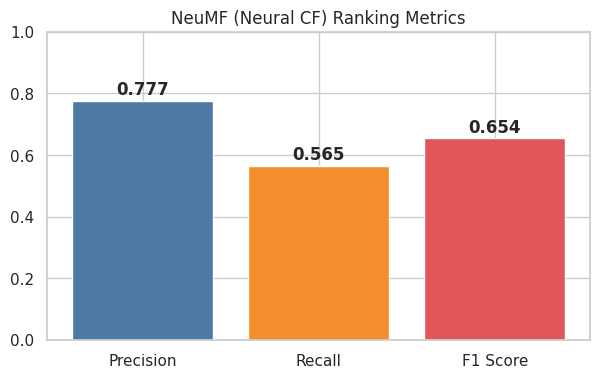

In [ ]:
# Scoring for NeuMF (Neural CF)
model.eval()
neumf_eval_list = []
with torch.no_grad():
    for row in test_df.itertuples():
        u_idx, i_idx = user_id_map.get(row.user_id, -1), movie_id_map.get(row.movie_id, -1)
        if u_idx != -1 and i_idx != -1:
            est = model(torch.tensor([u_idx]).to(device), torch.tensor([i_idx]).to(device)).item() * 4 + 1
            neumf_eval_list.append((row.user_id, row.movie_id, row.rating, est))

p_n, r_n, h_n = evaluate_ranking_metrics(neumf_eval_list, "NeuMF (Neural CF)")

# Evaluation

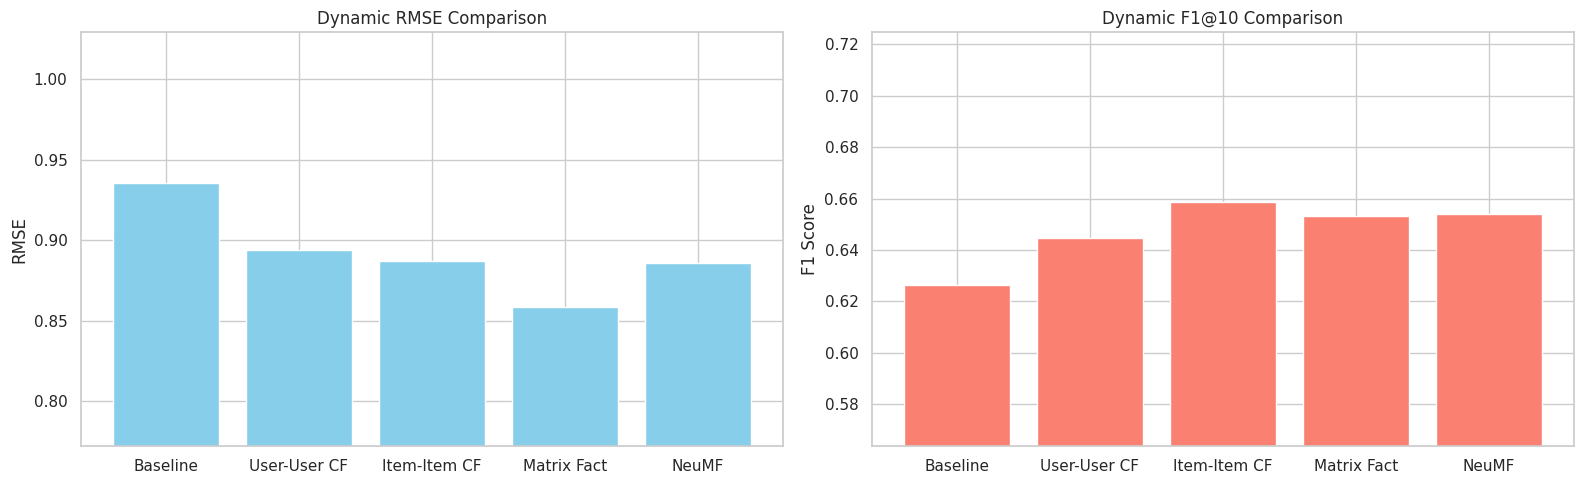

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def get_f1_score(predictions, k=10, threshold=3.5):
    user_est_true = {}
    for uid, _, true_r, est in predictions:
        if uid not in user_est_true: user_est_true[uid] = []
        user_est_true[uid].append((est, true_r))
    precisions, recalls = [], []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in user_ratings[:k])
        precisions.append(n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0)
        recalls.append(n_rel_and_rec_k / n_rel if n_rel != 0 else 0)
    avg_p, avg_r = np.mean(precisions), np.mean(recalls)
    return 2 * (avg_p * avg_r) / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0

# Dynamic data collection
models = ['Baseline', 'User-User CF', 'Item-Item CF', 'Matrix Fact', 'NeuMF']

# RMSE Extraction
rmse_vals = [
    calculate_rmse(test_df['rating'], test_df['pred_user_movie_bias']),
    calculate_rmse(test_df['rating'], test_df['pred_user_cf']),
    calculate_rmse(test_df['rating'], test_df['pred_item_cf']),
    final_test_rmse,
    best_val_rmse
]

# F1 Extraction
f1_vals = [
    get_f1_score(baseline_preds),
    get_f1_score(ucf_preds),
    get_f1_score(icf_preds),
    get_f1_score(mf_preds_list),
    get_f1_score(neumf_eval_list)
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.bar(models, rmse_vals, color='skyblue')
ax1.set_title('Dynamic RMSE Comparison')
ax1.set_ylabel('RMSE')
ax1.set_ylim(min(rmse_vals)*0.9, max(rmse_vals)*1.1)

ax2.bar(models, f1_vals, color='salmon')
ax2.set_title('Dynamic F1@10 Comparison')
ax2.set_ylabel('F1 Score')
ax2.set_ylim(min(f1_vals)*0.9, max(f1_vals)*1.1)

plt.tight_layout()
plt.show()

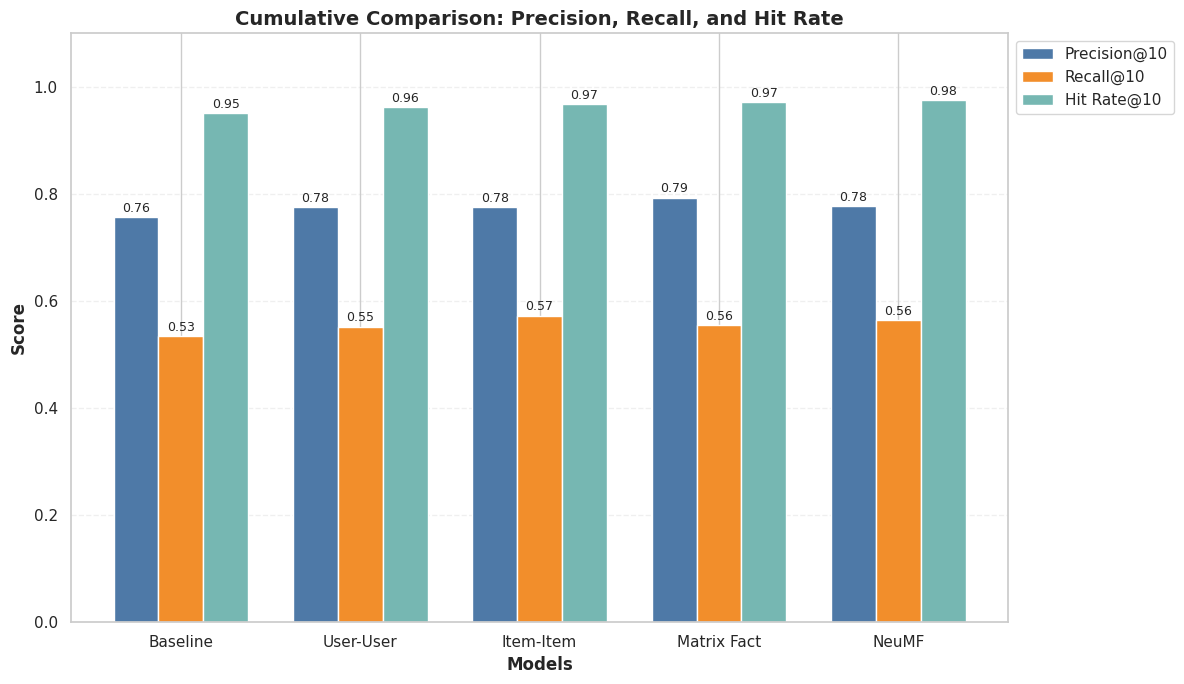

In [ ]:
models = ['Baseline', 'User-User', 'Item-Item', 'Matrix Fact', 'NeuMF']
precisions = [p_b, p_u, p_i, p_m, p_n]
recalls = [r_b, r_u, r_i, r_m, r_n]
hit_rates = [h_b, h_u, h_i, h_m, h_n]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12, 7))
plt.bar(x - width, precisions, width, label='Precision@10', color='#4e79a7')
plt.bar(x, recalls, width, label='Recall@10', color='#f28e2b')
plt.bar(x + width, hit_rates, width, label='Hit Rate@10', color='#76b7b2')

plt.xlabel('Models', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.title('Cumulative Comparison: Precision, Recall, and Hit Rate', fontsize=14, fontweight='bold')
plt.xticks(x, models)
plt.ylim(0, 1.1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.3)

for i in range(len(models)):
    plt.text(i - width, precisions[i] + 0.01, f'{precisions[i]:.2f}', ha='center', fontsize=9)
    plt.text(i, recalls[i] + 0.01, f'{recalls[i]:.2f}', ha='center', fontsize=9)
    plt.text(i + width, hit_rates[i] + 0.01, f'{hit_rates[i]:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()